# HW7 Programming: Linear Sarsa

**Paired Submission:** If you intend to work on this assignment with a partner, please form your pair _before_ you begin and work collaboratively on every written question and every component of the programming assignment. Make sure both partners are listed as group members on the last submissions to Gradescope.

**Your assignment is to:** implement linear Sarsa and apply it to the Mountain Car problem.

**You should start by duplicating this notebook:**
  - To save to your Google Drive, choose _File/Save a Copy in Drive…_ (from there you can open the file in Colab)
  - To save to your local machine, choose _File/Download/Download .ipnb_ (from there you can open the file in your favorite editor for notebooks)

When you submit, you will download the _.ipnb_ file and then upload it to Gradescope (details below).

# Installations and Imports

First we'll install some non-standard packages and libraries that we'll need.

In [17]:
!pip install gymnasium[classic-control]==1.2.1
!pip install pygame
!pip install pyvirtualdisplay
!apt update
!apt install xvfb

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
40 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as re

Now we'll import a bunch of packages that we'll need. (You might get some deprecation warnings that I haven't managed to get rid of, but the notebook still seems to run).

In [18]:
from tqdm.notebook import tqdm,trange    # To get nice progress bars
import matplotlib.pyplot as plt         # For plotting
import seaborn as sns
plt.rcParams['figure.dpi'] = 50

import gymnasium as gym
from gym.utils.play import play
from gym.wrappers import RecordVideo

import pyvirtualdisplay
d = pyvirtualdisplay.Display()
d.start() # Start Xvfb and set "DISPLAY" environment properly.

import base64
from base64 import b64encode
import io
from IPython.display import HTML
from IPython import display
from pyvirtualdisplay import Display

import math
import numpy as np
import random

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# TODO: `LinearQFunc`

In order to implement linear Sarsa, you'll need a linear value function.

To that end, implement the `LinearQFunc` class below.

The contructor should create an instance variable to represent the weights: a list of `numActions` lists, where each list contains `numFeats` 0s.

The `getQ` function takes a list of _indices_ of active features (features whose value is 1) as well as an action and should return the sume of the weights associated with that action and those features.

The `train` function takes a list of indices of active features, an action, an error value, and a step size. It should update the weights associated with the active features and the action using the error value and step size.



In [19]:
# TODO: implement this class

class LinearQFunc:
  def __init__(self, numFeats, numActions):
    # returns list of numAction lists where each list contains numFeat 0s
    self.w = [[0 for _ in range(numFeats)] for _ in range(numActions)]

  def getQ(self, activeFeats, action):
    """Takes a list of active feature indices and an action
       Returns the estimated q-value"""

    return sum(self.w[action][af] for af in activeFeats)

  def train(self, activeFeats, action, err, stepsize):
    """Takes
        - a list of active feature indices,
        - an action,
        - an error value
        - a step size
       Updates the weights for the action and active features
       using the error value and step size."""

    # w_A,i = w_A,i + alpha * delta
    for i in activeFeats:

      self.w[action][i] += stepsize * err

As a quick test, run the cell below which creates lists and active features and weights as a test case.

The correct output is:
```
[[0, 0, 0, 0], [0, 0, 0, 0]]
0
[[0.5, 0, 0.5, 0], [0, 0, 0, 0]]
1.0
```

In [20]:
testQ = LinearQFunc(4, 2)

testFeats = [0, 2]

# Print initial weights
print(testQ.w)
# Print initial q value
print(testQ.getQ(testFeats, 0))

testQ.train(testFeats, 0, 0.5, 1)
# Print updated weights
print(testQ.w)
# Print updated q value
print(testQ.getQ(testFeats, 0))

[[0, 0, 0, 0], [0, 0, 0, 0]]
0
[[0.5, 0, 0.5, 0], [0, 0, 0, 0]]
1.0


# `EpsilonGreedyPolicy`

Below you'll find an `EpsilonGreedyPolicy` class much like the ones we've implemented before. The main differences are:

- There is no longer a `Policy` superclass
- It expects a `LinearQFunc` instead of a dictionary
- It doesn't have an `actionsFor` function, just `chooseAction`
- `chooseAction` takes a list of active feature indices rather than a state

You don't need to edit this class.

In [21]:
class EpsilonGreedyPolicy:
  def __init__(self, numActions, q, epsilon):
    self.numActions = numActions
    self.q = q # We do NOT make a copy of q, so behavior will change as q changes
    self.epsilon = epsilon

  def chooseAction(self, activeFeatures):
    """Takes a list of active feature indices and returns an action,
       selected epsilon greedily"""
    if random.random() < self.epsilon:
      return random.randint(0, self.numActions-1)
    else:
      maxQ = -math.inf
      maxA = None
      for a in range(self.numActions):
        qVal = self.q.getQ(activeFeatures, a)
        if qVal > maxQ:
          maxQ = qVal
          maxA = a
      return maxA

# TODO: Feature Generator

The class below will be used to generate features for our linear Sarsa agent to use. In particular it will generate tile coding features for continuous state spaces.

There is one part of this class that you'll need to fill in: taking the coordinates of the state in each tiling and turning them into active feature indices. In particular, each grid square in each tiling needs to have a unique feature index.

For example, say there are two 3x3 tilings. Then one way to number the features would be:
```
FeatIdx   Dim 1   Dim 2  Tiling
   0        0       0       0
   1        1       0       0
   2        2       0       0
   3        0       1       0
   4        1       1       0
   5        2       1       0
   6        0       2       0
   7        1       2       0
   8        2       2       0
   9        0       0       1
  10        1       0       1
  11        2       0       1
  12        0       1       1
  13        1       1       1
  14        2       1       1
  15        0       2       1
  16        1       2       1
  17        2       2       1
```

Can you find a formula using the coordinates/tiling that produces the feature index?

In [22]:
# TODO: complete getActiveFeatures

class TileCodingFeatures:
  def __init__(self, ranges, numCells, numTilings):
    self.ranges = ranges
    self.numCells = numCells
    self.numTilings = numTilings

    self.widths = [r[1] - r[0] for r in ranges]
    self.cellWidths = [self.widths[d]/self.numCells[d] for d in range(len(self.widths))]
    self.offsets = [[random.uniform(-self.cellWidths[d], 0)/self.cellWidths[d] for d in range(len(self.cellWidths))] for t in range(self.numTilings)]

    self.numFeatures = 1
    for n in self.numCells:
      self.numFeatures *= (n+1)
    self.numFeatures *= self.numTilings

  def getActiveFeatures(self, state):
    activeFeatures = [None]*self.numTilings

    stateCells = [(state[d]-self.ranges[d][0])/self.cellWidths[d] for d in range(len(self.cellWidths))]

    for t in range(self.numTilings):
      coordinate = [int(stateCells[d]-self.offsets[t][d]) for d in range(len(self.ranges))]
      # Note: self.numCells[d] gives the number of cells along dimension d

      # current index is total number of cells in a tiling * t + dim 2 * num of cells in a row + dim 1
      # we need to add 1 to the numCells dimension since we have an extra row and colunn
      activeFeatures[t] =t * (self.numCells[0] + 1) * (self.numCells[1]+1) + coordinate[1] * (self.numCells[0]+1) + coordinate[0]

    return activeFeatures

  def getNumFeatures(self):
    return self.numFeatures

To quickly test your addition to the tile coding class, we can check your numbering of features in the example below.

There we will generate 3 4x4 tilings (which really become 5x5 tilings to accommodate the random offsets). The output will show the index corresponding to each grid square in each tiling.

In [23]:
numTestTilings = 3
numTestCells = 4

testTileCoding = TileCodingFeatures([(0, numTestCells)]*2, [numTestCells]*2, numTestTilings)

for t in range(numTestTilings):
  print("\nTiling " + str(t))
  for r in range(numTestCells+1):
    line = ""
    for c in range(numTestCells+1):
      testActiveFeats = testTileCoding.getActiveFeatures((c, r))
      line += str(testActiveFeats[t]) + "\t"
    print(line)


Tiling 0
0	1	2	3	4	
5	6	7	8	9	
10	11	12	13	14	
15	16	17	18	19	
20	21	22	23	24	

Tiling 1
25	26	27	28	29	
30	31	32	33	34	
35	36	37	38	39	
40	41	42	43	44	
45	46	47	48	49	

Tiling 2
50	51	52	53	54	
55	56	57	58	59	
60	61	62	63	64	
65	66	67	68	69	
70	71	72	73	74	


Note: the specific assignment of numbers to squares doesn't matter. The important thing is that each square gets a _unique_ feature index.

As an example, here is how _my_ code numbers the features (yours may not match mine exactly):
```
Tiling 0
0	5	10	15	20
1	6	11	16	21
2	7	12	17	22
3	8	13	18	23
4	9	14	19	24

Tiling 1
25	30	35	40	45
26	31	36	41	46
27	32	37	42	47
28	33	38	43	48
29	34	39	44	49

Tiling 2
50	55	60	65	70
51	56	61	66	71
52	57	62	67	72
53	58	63	68	73
54	59	64	69	74
```

# TODO: Linear Sarsa

Now that you have a feature generator, it's time to implement linear Sarsa.

The implementation below is a correct implementation of Sarsa, like the one you worked with in the past. It builds a table that associates each state-action pair with a value.

The main difference is that, instead of working with our old MDP class, this implementation has been adapted to work with a [Gymnasium](https://gymnasium.farama.org/index.html) environment. Gymnasium is a library that started under OpenAI and has since moved to The Farama Foundation, a non-profit organization specifically founded to maintain RL environment libraries. Gymnasium collects several common RL benchmark problems under a unified interface so they are easier to experiment with.

In a problem with a huge or continuous state space, a table-lookup value function won't work! Your job is to adapt this implementation to use a linear value function instead.



In [24]:
# TODO: Convert this to actually be linear sarsa!!

def linearSarsa(env, featGenerator, numEpisodes=10000, gamma=0.9, alpha=0.1, epsilon=0.1, progressBar=True):
  """Take an Gymnasium environment env and a feature generator and return
     - The agent's policy after training
     - The agent's value function after training
     - A list of total rewards for each episode during training

     Optional parameters:
     - numEpisodes (default 10000): number of episodes to perform
     - gamma (default 1): the discount rate
     - epsilon (default 0.1): the exploration rate
     - alpha (default 0.1): the step size
     - progressBar (default True): if True, displays a progress bar counting training episodes"""

  numActions = env.action_space.n # number of actions

  # Init the linear q function
  numFeatures = featGenerator.getNumFeatures() # number of features
  q = LinearQFunc(numFeats= numFeatures, numActions= numActions)
  epScores = []

  pi = EpsilonGreedyPolicy(numActions, q, epsilon)  # This policy will change as q changes

  for i in tqdm(range(numEpisodes), desc="Sarsa Eps", disable=not progressBar):
    epScores.append(0)

    curS = env.reset()[0] # getting first element to strip the info
    # print(curS)
    activeFeatures = featGenerator.getActiveFeatures(curS)
    # print(activeFeatures)
    curA = pi.chooseAction(activeFeatures)  # <- the policy wants features, not a state

    step = 0
    term = False
    trunc = False
    while not (term or trunc):
      nextS, r, term, trunc, info = env.step(curA)
      # print(info)
      epScores[-1] += r

      # curVal = q.get((curS, curA), 0)  # <- this will need to change
      curVal = q.getQ(activeFeatures, curA)
      delta = r - curVal
      if not term:
        nextActiveFeatures = featGenerator.getActiveFeatures(nextS)
        nextA = pi.chooseAction(nextActiveFeatures )  # <- the policy wants features, not a state
        nextVal = q.getQ(nextActiveFeatures, nextA)
        delta += gamma*nextVal
      else:
        nextA = None

      # q[curS, curA] += alpha*delta   # <- this will need to change
      q.train(activeFeatures, curA, delta, alpha)

      # Finally, move time forward and loop back around
      curS = nextS
      curA = nextA
      if not (term or trunc):
        activeFeatures = nextActiveFeatures

  return pi, q, epScores

In [25]:
# ranges = [(-1.2, 0.6), (-0.07, 0.07)]
# featGenerator = TileCodingFeatures(ranges, (8, 8), 8)

# for t in range(8):
#   for r in range(8+1):
#     line = ""
#     # print(len(testActiveFeats))
#     for c in range(8+1):
#       testActiveFeats = featGenerator.getActiveFeatures((c, r))
#       line += str(testActiveFeats[t]) + "\t"
#     print(line)

# TODO: Test Linear Sarsa

Run the cell below to apply your linear sarsa function to the Mountain Car problem in one trial for 250 episodes. We set $\epsilon=0$, so we are relying on optimistic initialization for exploration.

It'll take a while to train because it's going to record some videos!

In [26]:
ranges = [(-1.2, 0.6), (-0.07, 0.07)]
featGenerator = TileCodingFeatures(ranges, (8, 8), 8)
vidEps = [0, 49, 249]
vidMCar = RecordVideo(gym.make('MountainCar-v0', render_mode="rgb_array"), "./", name_prefix="test", new_step_api=True, episode_trigger=lambda ep : ep in vidEps)
pi, q, epScores = linearSarsa(vidMCar, featGenerator, numEpisodes=251, alpha=0.5/8, epsilon=0)

/usr/local/lib/python3.12/dist-packages/gym/wrappers/record_video.py:78: UserWarning: WARN: Overwriting existing videos at /content folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Sarsa Eps:   0%|          | 0/251 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


This cell will define a function that displays a video in the notebook.

Then the cells below this will show videos of your agent's performance during learning!

In [27]:
def showVideo(filename):
  mp4 = open(filename,'rb').read()
  data_url = "data:video/mp4;base64," + base64.b64encode(mp4).decode()
  return HTML("""
  <video width=400 controls>
        <source src="%s" type="video/mp4">
  </video>
  """ % data_url)

This video shows the agent in episode 0.

You should be able to see it start to explore by rolling higher up the hill in both directions.

Note that Gym cuts off the episode after 200 steps no matter what, so the video will end before the agent escapes the valley.

In [28]:
showVideo("test-episode-0.mp4")

This video shows your agent in its 50th episode. You should see it getting much higher than before. If you are lucky, you might even get to see it escape the valley, but you might not.

In [29]:
showVideo("test-episode-49.mp4")

This video shows your agent in the 250th episode. In my results, it pretty consistently escapes the valley by this point.

In [30]:
showVideo("test-episode-249.mp4")

The following cell will plot the policy and value function after 250 episodes as heatmaps.

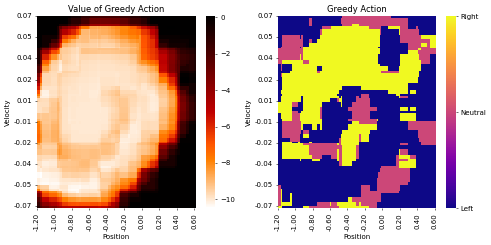

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [31]:
# Do not change the contents of this cell!

def heatmaps(pi, q, featureGenerator):
  posPoints = 100
  velPoints = 100
  actHeatmap = np.zeros((posPoints+1, velPoints+1))
  valHeatmap = np.zeros((posPoints+1, velPoints+1))
  for p in range(posPoints+1):
    pos = ranges[0][0] + p/posPoints*(ranges[0][1] - ranges[0][0])
    for v in range(velPoints+1):
      vel = ranges[1][0] + (velPoints - v)/velPoints*(ranges[1][1] - ranges[1][0])

      feats = featureGenerator.getActiveFeatures((pos, vel))
      greedyAct = pi.chooseAction(feats)
      actHeatmap[v, p] = greedyAct
      valHeatmap[v, p] = q.getQ(feats, greedyAct)
  return actHeatmap, valHeatmap

def plotHeatmaps(pi, q, featureGenerator):
  numRows = 1
  numCols = 2
  fig, ax = plt.subplots(numRows, numCols, figsize=(5*numCols, 5*numRows))

  actHeatmap, valHeatmap = heatmaps(pi, q, featureGenerator)

  valueColormap = "gist_heat_r"
  sns.heatmap(valHeatmap, ax=ax[0], cmap=valueColormap)
  ax[0].set_title("Value of Greedy Action")
  ax[0].set_xlabel("Position")
  ax[0].set_ylabel("Velocity")
  ax[0].set_xticks(np.linspace(0, 100, 10))
  ax[0].set_xticklabels(f'{c:.2f}' for c in np.linspace(ranges[0][0], ranges[0][1], 10))
  ax[0].set_yticks(np.linspace(0, 100, 10))
  ax[0].set_yticklabels(f'{c:.2f}' for c in np.linspace(ranges[1][1], ranges[1][0], 10))

  policyColormap = "plasma"
  sns.heatmap(actHeatmap, ax=ax[1], cmap=policyColormap)
  ax[1].set_title("Greedy Action")
  ax[1].set_title("Greedy Action")
  ax[1].set_xlabel("Position")
  ax[1].set_ylabel("Velocity")
  ax[1].set_xticks(np.linspace(0, 100, 10))
  ax[1].set_xticklabels(f'{c:.2f}' for c in np.linspace(ranges[0][0], ranges[0][1], 10))
  ax[1].set_yticks(np.linspace(0, 100, 10))
  ax[1].set_yticklabels(f'{c:.2f}' for c in np.linspace(ranges[1][1], ranges[1][0], 10))
  cbar = ax[1].collections[0].colorbar
  cbar.set_ticks([0, 1, 2])
  cbar.set_ticklabels(["Left", "Neutral", "Right"])

  plt.tight_layout()
  plt.show();

plotHeatmaps(pi, q, featGenerator)

Since we are looking at just one trial, the exact shape that you get will probably differ from mine in its details, but you should see the characteristic spiral shape in the value function, showing the agent's path moving back and then forward in position and correspondingly negative and then positive in velocity.

Similarly, you should see the spiral shape in the policy with the agent choosing left until it reaches the left side with a nearly 0 velocity, and then switching to right until it escapes on the right side.

For comparison, my results look like this:

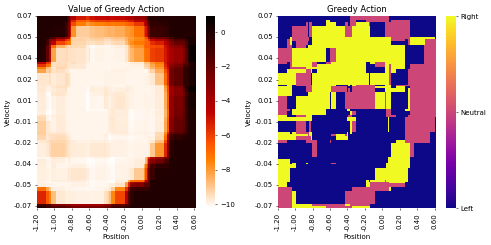

# TODO: Experiment with Step Size

Finally, you'll run an experiment comparing the performance of difference step sizes and difference numbers of tilings.

The first plot will show results using 4 tilings and the second will show results using 8 tilings.

alpha=0.025:   0%|          | 0/50 [00:00<?, ?it/s]

alpha=0.05:   0%|          | 0/50 [00:00<?, ?it/s]

alpha=0.1:   0%|          | 0/50 [00:00<?, ?it/s]

alpha=0.2:   0%|          | 0/50 [00:00<?, ?it/s]

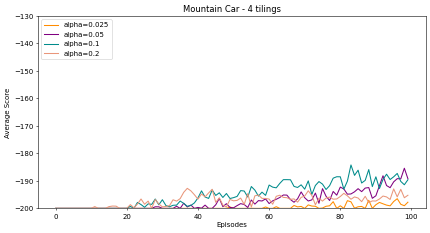

alpha=0.025:   0%|          | 0/50 [00:00<?, ?it/s]

alpha=0.05:   0%|          | 0/50 [00:00<?, ?it/s]

alpha=0.1:   0%|          | 0/50 [00:00<?, ?it/s]

alpha=0.2:   0%|          | 0/50 [00:00<?, ?it/s]

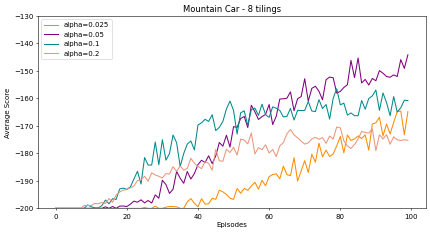

In [32]:
# Do not change the contents of this cell!

def plot_avg_scores(scores, names, colors, title):
  fig, ax = plt.subplots(1, figsize=(10, 5))

  ax.set_xlabel("Episodes")
  ax.set_ylabel("Average Score")
  xs = range(len(scores[0]))
  for i in range(len(scores)):
    ax.plot(xs, scores[i], label=names[i], c=colors[i])
  ax.set_title(title)
  ax.legend(loc='upper left')
  ax.set_ylim(-200, -130)

  plt.show();

mCar = gym.make('MountainCar-v0')

numTrials = 50
numEps = 100

alphas = [0.025, 0.05, 0.1, 0.2]
for nTilings in [4, 8]:
  featGen = TileCodingFeatures(ranges, (8, 8), nTilings)
  colors=["darkorange", "purple", "darkcyan", "darksalmon"]
  scores = [[0]*numEps for a in alphas]
  names = ["alpha="+str(a) for a in alphas]
  for alg in range(len(alphas)):
    for trial in trange(numTrials, desc=names[alg]):
      resultPi, resultQ, resultScores = linearSarsa(mCar, featGen, alpha=alphas[alg], numEpisodes=numEps, progressBar=False, epsilon=0)
      for i in range(numEps):
        scores[alg][i] += resultScores[i]/numTrials

  plot_avg_scores(scores, names, colors, "Mountain Car - " + str(nTilings) + " tilings")

You should see results consistent with our theoretical predictions:

*   The agent using 8 tilings should perform better overall than the one using 4 tilings, because more tilings allows for a more expressive value function that can more closely approximate the true value function.
*   The agent using 8 tilings can do well with smaller stepsizes than the agent using 4 tilings, because doubling the number of features doubles the size of the update.

For comparison, here are my results. Yours will differ, but should be qualitatively similar:




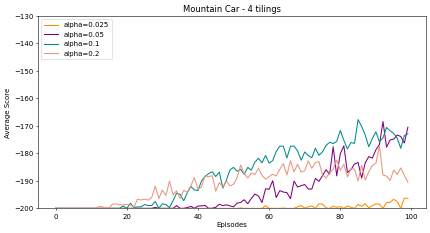

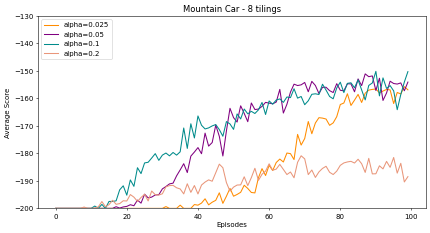

# TODO: Submit!

1. Make sure that the output of all cells is up-to-date (easiest way is to choose _Runtime/Run all_).
2. If you are working in Colab, choose _File/Download/Download .ipnb_ (otherwise locate your _.ipnb_ file)
3. Go to the Gradescope assignment to submit.
4. Choose _Upload_ as the submission method and upload your _.ipnb_ file.
5. If you are working as a pair, make sure to push the _Group Members_ button to add the other partner.